In [1]:
# (데이터 증강 + CNN 개선)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 학습 데이터 불러오기
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/OSS/dataset/raw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 1574 files belonging to 4 classes.
Using 1260 files for training.
Found 1574 files belonging to 4 classes.
Using 314 files for validation.


In [3]:
# 클래스 이름
class_names = train_ds.class_names

print("클래스 목록")
print(class_names)

클래스 목록
['can', 'paper', 'plastic', 'vinyl']


In [4]:
# 데이터 증강
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [5]:
# 모델 생성
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),


    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [6]:
# 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# 조기종료
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True
)

In [8]:
# 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 471s 11s/step - accuracy: 0.5246 - loss: 25.4014 - val_accuracy: 0.3344 - val_loss: 9.9942
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 272s 7s/step - accuracy: 0.6238 - loss: 13.8332 - val_accuracy: 0.3057 - val_loss: 17.4068
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 261s 6s/step - accuracy: 0.5571 - loss: 7.8922 - val_accuracy: 0.2580 - val_loss: 4.7690
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 261s 6s/step - accuracy: 0.5810 - loss: 4.0554 - val_accuracy: 0.3185 - val_loss: 6.6760
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 277s 7s/step - accuracy: 0.6214 - loss: 3.0509 - val_accuracy: 0.5255 - val_loss: 1.9247
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 261s 6s/step - accuracy: 0.6262 - loss: 1.9270 - val_accuracy: 0.2771 - val_loss: 1.9595
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 278s 7s/step - accuracy: 0.6333 - loss: 1.2251 - val_accuracy: 0.3567 - val_loss: 1.9583
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 283s 7s/step - accuracy: 0.6325 - loss: 1.4224 - val_accuracy: 0.2611

In [9]:
# 평가
loss, acc = model.evaluate(val_ds)

print(f"Validation Accuracy : {acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5255 - loss: 1.9247
Validation Accuracy : 0.5255


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[38  6  4  5]
 [ 4 75  4 13]
 [ 4 13 59  9]
 [ 2 11  5 62]]


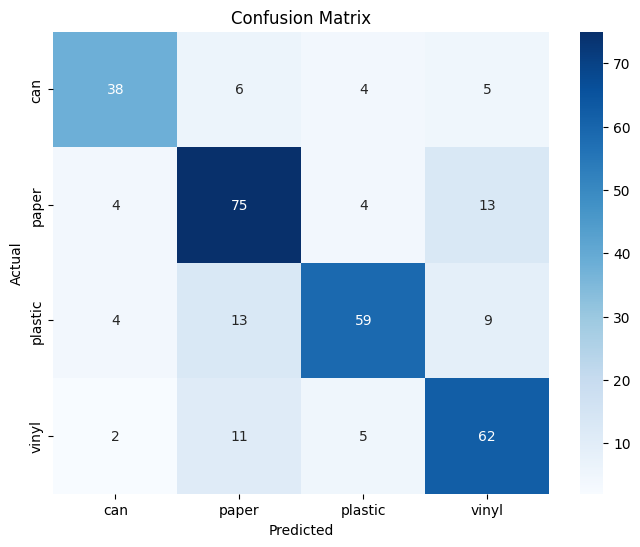

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# 모델 저장
model.save(
    "/content/drive/MyDrive/OSS/AI/model/recycle_model_v2.keras"
)

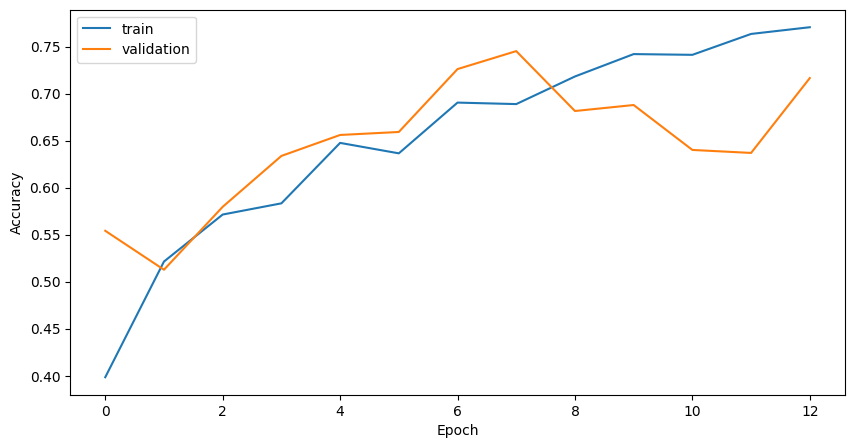

In [ ]:
import matplotlib.pyplot as plt

# 그래프
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
print(history.history['val_loss'])
print(history.history['val_accuracy'])

[1.3740507364273071, 1.3163418769836426, 1.3107980489730835, 1.3809622526168823, 1.4217841625213623, 1.4514769315719604, 1.4104909896850586, 1.3210638761520386]
[0.25, 0.38999998569488525, 0.41999998688697815, 0.46000000834465027, 0.4300000071525574, 0.4699999988079071, 0.41999998688697815, 0.49000000953674316]


In [ ]:
print(max(history.history['val_accuracy']))

0.49000000953674316
